# Práctica 3: Problema del Agente Viajero (TSP) — Clase **NP-completo**
### Complejidad Computacional · Facultad de Ciencias, UNAM

---

## 1. Contexto teórico

El **Traveling Salesman Problem (TSP)** es quizá el problema de optimización
combinatoria más famoso. El problema de decisión es:

> **TSP-DEC:** Dada una gráfica completa dirigida y ponderada $G = (V, E, w)$
> y un presupuesto $B$, ¿existe un circuito hamiltoniano de costo total $\leq B$?

Un **circuito hamiltoniano** visita cada vértice exactamente una vez y regresa
al origen.

**Datos clave:**
- TSP-DEC es **NP-completo** (Karp, 1972).
- El algoritmo de **fuerza bruta** revisa todas las permutaciones: $O(n!)$.
- El algoritmo de **Held-Karp** (1962) usa programación dinámica: $O(2^n \cdot n^2)$.
- Ambos son **exponenciales**, pero Held-Karp es dramáticamente más rápido.
- No se conoce ningún algoritmo exacto polinomial (y probablemente no existe,
  a menos que $P = NP$).

---

## 2. Objetivo

1. Implementar fuerza bruta con `itertools.permutations`.
2. Implementar el algoritmo de Held-Karp con **bitmask DP**.
3. Comparar tiempos y entender la diferencia entre $O(n!)$ y $O(2^n \cdot n^2)$.
4. Discutir aproximaciones y heurísticas.

## 3. Mini-tutorial de Python

```python
from itertools import permutations

# --- Permutaciones ---
lista = [1, 2, 3]
for perm in permutations(lista):
    print(perm)   # (1,2,3), (1,3,2), (2,1,3), (2,3,1), (3,1,2), (3,2,1)

# --- Bitmask (máscara de bits) para subconjuntos ---
# S es el conjunto de vértices visitados, representado como un entero.
n = 4
S = 0b1011   # bits 0, 1 y 3 encendidos → vértices {0, 1, 3} visitados

# ¿Está el vértice i en S?
i = 2
print((S >> i) & 1)   # 0 → no está en S

# Agregar el vértice j a S:
j = 2
S_nuevo = S | (1 << j)    # S | (bit j encendido)

# Quitar el vértice i de S:
S_sin_i = S & ~(1 << i)   # S con el bit i apagado

# Conjunto completo de n vértices:
S_completo = (1 << n) - 1  # todos los n bits encendidos

# --- Matrices como listas de listas ---
dist = [[0, 2, 9, 10],
        [1, 0, 6,  4],
        [15, 7, 0, 8],
        [6, 3, 12, 0]]
# dist[i][j] = costo de ir del nodo i al nodo j
```

In [1]:
# ── Celda 1: Importaciones ────────────────────────────────────────────────────

import time
import random
import math
import matplotlib.pyplot as plt
from itertools import permutations

print("✓ Importaciones listas.")

✓ Importaciones listas.


## 4. Algoritmo 1: Fuerza bruta

**Idea:** generar todas las permutaciones de los nodos $\{1, 2, \ldots, n-1\}$
(fijamos el nodo 0 como inicio/fin), calcular el costo de cada circuito,
y devolver el mínimo.

**Complejidad:** $O((n-1)!) = O(n!)$ — crece factorialmente.

In [2]:
# ── Celda 2: Fuerza bruta ─────────────────────────────────────────────────────

def tsp_fuerza_bruta(dist):
    '''
    Encuentra el circuito hamiltoniano de costo mínimo.
    Algoritmo: fuerza bruta — prueba todas las permutaciones.
    Complejidad: O(n!)

    Parámetro:
        dist : matriz n×n de costos (dist[i][j] = costo de i→j)
    Devuelve:
        (costo_minimo, mejor_circuito)
    '''
    n = len(dist)
    nodos_intermedios = list(range(1, n))  # todos los nodos excepto el nodo 0

    min_costo   = float('inf')
    mejor_ruta  = None

    for perm in permutations(nodos_intermedios):
        # El circuito completo empieza y termina en el nodo 0
        ruta = (0,) + perm + (0,)

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 1 — Calcular el costo total del circuito                  ║
        # ║                                                                  ║
        # ║  El circuito es: ruta[0] → ruta[1] → ... → ruta[n] → ruta[0]   ║
        # ║  donde ruta ya incluye el nodo 0 al inicio y al final.          ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Inicializa  costo = 0                                        ║
        # ║  2. Para cada i en range(n):  (el circuito tiene n aristas)     ║
        # ║       costo += dist[ruta[i]][ruta[i+1]]                         ║
        # ║     (ruta tiene n+1 elementos: índices 0 hasta n)               ║
        # ╚═══════════════════════════════════════════════════════════════════╝

        costo = 0
        for i in range(n):
            costo += dist[ruta[i]][ruta[i+1]]

        if costo < min_costo:
            min_costo  = costo
            mejor_ruta = ruta

    return min_costo, mejor_ruta


# ── Prueba con la instancia clásica de 4 nodos ────────────────────────────────
dist_ej = [[0, 2, 9, 10],
           [1, 0, 6,  4],
           [15, 7, 0, 8],
           [6, 3, 12, 0]]

costo, ruta = tsp_fuerza_bruta(dist_ej)
print(f"Costo mínimo (fuerza bruta): {costo}")
print(f"Ruta: {ruta}")
print("Esperado: costo = 21, ruta = (0, 1, 3, 2, 0)")

Costo mínimo (fuerza bruta): 21
Ruta: (0, 2, 3, 1, 0)
Esperado: costo = 21, ruta = (0, 1, 3, 2, 0)


## 5. Algoritmo 2: Held-Karp (bitmask DP)

**Idea:** usamos programación dinámica con la siguiente definición:

$$dp[S][i] = \text{costo mínimo de ir del nodo } 0,$$
$$\text{visitar exactamente los nodos en el conjunto } S, \text{ y terminar en el nodo } i$$

donde $S$ es un subconjunto de nodos representado como máscara de bits.

**Transición:** para agregar el nodo $j \notin S$ después de estar en $i \in S$:
$$dp[S \cup \{j\}][j] = \min\left(dp[S \cup \{j\}][j],\; dp[S][i] + \text{dist}[i][j]\right)$$

**Caso base:** $dp[\{0\}][0] = 0$ (en el nodo 0, sin haber visitado nadie más).

**Solución:** $\min_{i \neq 0} \left( dp[S_{\text{total}}][i] + \text{dist}[i][0] \right)$
donde $S_{\text{total}} = \{0, 1, \ldots, n-1\}$.

In [3]:
# ── Celda 3: Held-Karp ────────────────────────────────────────────────────────

def tsp_held_karp(dist):
    '''
    Encuentra el circuito hamiltoniano de costo mínimo.
    Algoritmo: Held-Karp (DP con bitmask).
    Complejidad: O(2^n * n^2)

    Parámetro:
        dist : matriz n×n de costos
    Devuelve:
        costo_minimo (float)
    '''
    n   = len(dist)
    INF = float('inf')

    # dp[S][i] = costo mínimo de ir del nodo 0,
    #            visitar los nodos en S, y terminar en el nodo i.
    # S va de 0 a (2^n - 1) como máscara de bits.
    dp = [[INF] * n for _ in range(1 << n)]

    # Caso base: estamos en el nodo 0, conjunto visitado = {0} = bitmask 1
    dp[1][0] = 0

    for S in range(1, 1 << n):          # recorre todos los subconjuntos
        for i in range(n):              # último nodo visitado
            if not (S >> i) & 1:
                continue                # i no está en S, saltamos
            if dp[S][i] == INF:
                continue                # no hay camino hasta (S, i), saltamos

            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  TODO 2 — Extender el camino al nodo j (j ∉ S)             ║
            # ║                                                              ║
            # ║  Para cada nodo j en range(n):                              ║
            # ║    Si el bit j de S está apagado (j no está en S):          ║
            # ║      S_nuevo = S con el bit j encendido  →  S | (1 << j)   ║
            # ║      nuevo_costo = dp[S][i] + dist[i][j]                   ║
            # ║      Si nuevo_costo < dp[S_nuevo][j]:                       ║
            # ║          dp[S_nuevo][j] = nuevo_costo                       ║
            # ╚═══════════════════════════════════════════════════════════════╝

            for j in range(n):
                if not (S >> j) & 1:
                    S_nuevo = S | (1 << j)
                    nuevo_costo = dp[S][i] + dist[i][j]
                    if nuevo_costo < dp[S_nuevo][j]:
                        dp[S_nuevo][j] = nuevo_costo

    # Cerrar el circuito: regresar al nodo 0 desde cada nodo i
    S_completo = (1 << n) - 1   # todos los bits encendidos
    min_costo  = INF

    for i in range(1, n):   # no incluimos i=0 (ya es el nodo de regreso)
        costo = dp[S_completo][i] + dist[i][0]
        if costo < min_costo:
            min_costo = costo

    return min_costo


# ── Prueba ────────────────────────────────────────────────────────────────────
costo_hk = tsp_held_karp(dist_ej)
print(f"Costo mínimo (Held-Karp): {costo_hk}")
print(f"¿Coincide con fuerza bruta? {abs(costo_hk - costo) < 1e-9}")

Costo mínimo (Held-Karp): 21
¿Coincide con fuerza bruta? True


In [4]:
# ── Celda 4: Validación cruzada ───────────────────────────────────────────────
# Generamos 50 instancias aleatorias pequeñas y verificamos que ambos
# algoritmos producen el mismo costo mínimo.

def generar_tsp(n, semilla=None):
    random.seed(semilla)
    return [[0 if i == j else random.randint(1, 100)
             for j in range(n)] for i in range(n)]

errores = 0
for k in range(50):
    n_k   = random.randint(3, 8)
    d_k   = generar_tsp(n_k, semilla=k)
    c_fb, _ = tsp_fuerza_bruta(d_k)
    c_hk    = tsp_held_karp(d_k)
    if abs(c_fb - c_hk) > 1e-9:
        errores += 1
        print(f"  ✗ Discrepancia en instancia {k}: FB={c_fb}, HK={c_hk}")

if errores == 0:
    print("✓ 50 instancias aleatorias: fuerza bruta y Held-Karp coinciden.")

✓ 50 instancias aleatorias: fuerza bruta y Held-Karp coinciden.


## 6. Medición de tiempos

In [5]:
# ── Celda 5: Tiempos — fuerza bruta ──────────────────────────────────────────

tamanos_fb = list(range(3, 13))   # n = 3..12  (¡no más! n=13 ya tarda mucho)
tiempos_fb = []
REPS = 3

print(f"{'n':>5}  {'tiempo FB (s)':>16}")
print("-" * 25)

for n in tamanos_fb:
    ts = []
    for rep in range(REPS):
        d = generar_tsp(n, semilla=rep * 31 + n)
        t0 = time.perf_counter()
        tsp_fuerza_bruta(d)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_fb.append(promedio)
    print(f"{n:>5}  {promedio:>16.6f}")

    n     tiempo FB (s)
-------------------------
    3          0.000010
    4          0.000010
    5          0.000028
    6          0.000137
    7          0.001102
    8          0.007458
    9          0.033297
   10          0.245309
   11          2.634217
   12         31.110840


In [6]:
# ── Celda 6: Tiempos — Held-Karp ─────────────────────────────────────────────

tamanos_hk = list(range(3, 21))   # n = 3..20  (Held-Karp escala mejor)
tiempos_hk = []

print(f"{'n':>5}  {'tiempo HK (s)':>16}")
print("-" * 25)

for n in tamanos_hk:
    ts = []
    for rep in range(REPS):
        d = generar_tsp(n, semilla=rep * 31 + n)
        t0 = time.perf_counter()
        tsp_held_karp(d)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_hk.append(promedio)
    print(f"{n:>5}  {promedio:>16.6f}")

    n     tiempo HK (s)
-------------------------
    3          0.000013
    4          0.000020
    5          0.000053
    6          0.000130
    7          0.000313
    8          0.000606
    9          0.001272
   10          0.003139
   11          0.007438
   12          0.016688
   13          0.053720
   14          0.089762
   15          0.204690
   16          0.510613
   17          1.082060
   18          2.505620
   19          5.378145
   20         11.980690


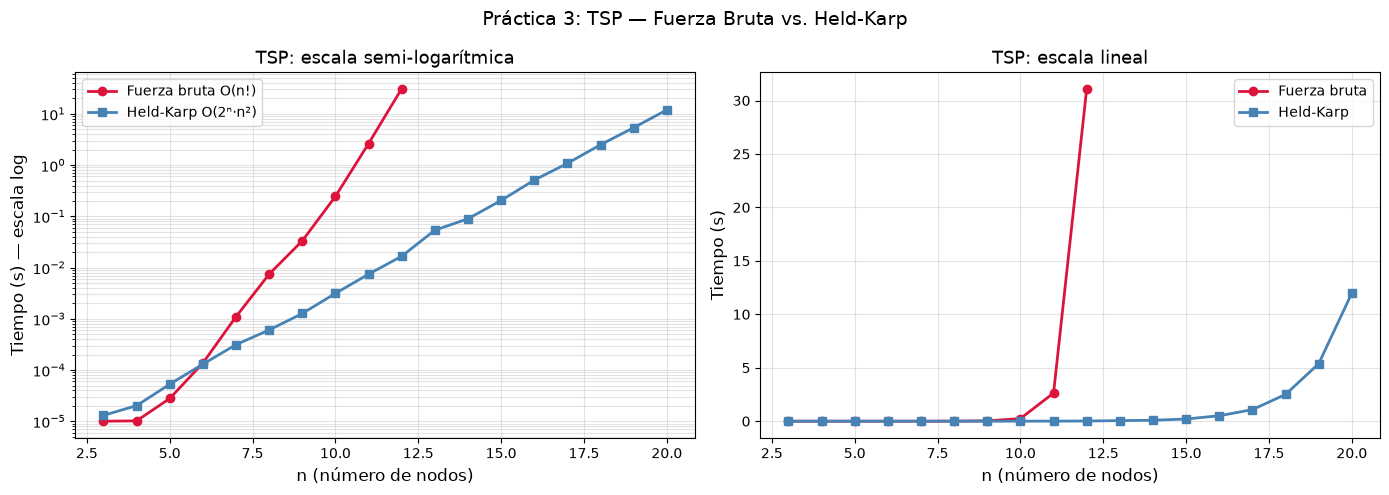

Gráfica guardada como  03_tsp_tiempos.png


In [7]:
# ── Celda 7: Gráfica ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(tamanos_fb, tiempos_fb, "o-", color="crimson",   lw=2, label="Fuerza bruta O(n!)")
axes[0].semilogy(tamanos_hk, tiempos_hk, "s-", color="steelblue", lw=2, label="Held-Karp O(2ⁿ·n²)")
axes[0].set_xlabel("n (número de nodos)", fontsize=12)
axes[0].set_ylabel("Tiempo (s) — escala log", fontsize=12)
axes[0].set_title("TSP: escala semi-logarítmica", fontsize=13)
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.35)

axes[1].plot(tamanos_fb, tiempos_fb, "o-", color="crimson",   lw=2, label="Fuerza bruta")
axes[1].plot(tamanos_hk, tiempos_hk, "s-", color="steelblue", lw=2, label="Held-Karp")
axes[1].set_xlabel("n (número de nodos)", fontsize=12)
axes[1].set_ylabel("Tiempo (s)", fontsize=12)
axes[1].set_title("TSP: escala lineal", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.35)

plt.suptitle("Práctica 3: TSP — Fuerza Bruta vs. Held-Karp", fontsize=14)
plt.tight_layout()
plt.savefig("03_tsp_tiempos.png", dpi=110, bbox_inches="tight")
plt.show()
print("Gráfica guardada como  03_tsp_tiempos.png")

## 7. Preguntas de análisis

**Q1.** Tanto fuerza bruta como Held-Karp son exponenciales.
¿Por qué Held-Karp es considerado un avance importante si ambos son exponenciales?\\
Porque la tasa de crecimiento factorial $O(n!)$ domina a la exponencial $O(2^n)$. El algoritmo de fuerza bruta revisa ramas redundantes muchas de veces, haciéndose intratable alrededor de $n = 13$ o $14$ pero el algoritmo de Held-Karp, como usa Programación Dinámica, entonces tiene memoria de los subcaminos óptimos y evita recalcularlos.

**Q2.** Calcula teóricamente cuánto tiempo tardaría un computador que resuelve
$10^9$ operaciones por segundo en resolver TSP con $n = 50$ usando:
(a) fuerza bruta: $50! / 10^9$ segundos, (b) Held-Karp: $2^{50} \cdot 50^2 / 10^9$ segundos.
Convierte a años si es necesario.\\
(a) $50! \approx 3.04 \times 10^{64}$ operaciones y eso al dividirlo entre $10^9$, da $\approx 3.04 \times 10^{55}$ segundos. Convertido a años, son aproximadamente $9.6 \times 10^{47}$ años.\\
(b) $2^{50} \cdot 2500 \approx 2.81 \times 10^{18}$ operaciones y al dividirlo entre $10^9$, da $2.81 \times 10^9$ segundos. Y en años, son aproximadamente 89 años.

**Q3.** En la práctica, se usan **heurísticas** (vecino más cercano, 2-opt, Lin-Kernighan)
y **aproximaciones** (Christofides garantiza una solución a lo más $3/2$ del óptimo).
¿Cuál sería la ventaja y desventaja de usar Christofides en lugar de Held-Karp?\\
Ventaja: El algoritmo de Christofides puede resolver instancias de  millones de nodos en minutos.\\
Desventajas: El algoritmo de Christofides solo es un algoritmo de aproximación; y no garantiza encontrar la ruta 100% óptima, solo garantiza que la ruta encontrada no será peor que el 150% de la ruta óptima real.

**Q4.** TSP es NP-completo, pero el **TSP métrico** (donde las distancias satisfacen
la desigualdad triangular) admite aproximaciones de tiempo polinomial.
¿Por qué crees que el caso métrico es más tratable?\\
El caso métrico respeta la regla de que "ir directo de A hacia C siempre es igual o más barato que pasar por B". Esta restricción geométrica es importante ya que permite que los algoritmos de aproximación construyan un Árbol de Expansión Mínima y luego tomen atajos para saltarse nodos repetidos al formar el circuito, y debido a la desigualdad triangular, se sabe que tomar el atajo no incrementa el costo de la ruta, lo que da un límite superior garantizado.

**Q5.** Si $P \neq NP$, ¿es posible que exista un algoritmo de tiempo $O(n^{100})$
para TSP? ¿Sería útil en la práctica?\\
No, ya que por definición, si se asume que $P \neq NP$, entonces es imposible que exista un algoritmo de tiempo polinomial para resolver de forma exacta un problema NP-completo como el TSP, y de lo contrario, si existiera, en la práctica un algoritmo $O(n^{100})$ no sería útil.